In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

In [2]:
csv_name = "household_data_15min_singleindex.csv"

csv_path = None
for root in [Path.cwd(), *Path.cwd().parents]:
    candidate = root / "data" / csv_name
    if candidate.exists():
        csv_path = candidate
        break

if csv_path is None:
    raise FileNotFoundError("Dataset not found")

print("Loading from:", csv_path)

df = pd.read_csv(csv_path)
df.head()

Loading from: C:\Users\test\OneDrive\Documents\GitHub\DataScienceCapstone\data\household_data_15min_singleindex.csv


,utc_timestamp,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
0,2014-12-11T17:45:00Z,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T18:15:00Z,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T18:30:00Z,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T18:45:00Z,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df["cet_cest_timestamp"] = pd.to_datetime(df["cet_cest_timestamp"], utc=True)
df = df.sort_values("cet_cest_timestamp")

# Select residential3
cols = [c for c in df.columns if c.startswith("DE_KN_residential3")]
res = df[["cet_cest_timestamp"] + cols].copy()

res.set_index("cet_cest_timestamp", inplace=True)
res.index = res.index.tz_convert("Europe/Berlin").tz_localize(None)

res = res.dropna()

res.head()

,DE_KN_residential3_circulation_pump,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_refrigerator,DE_KN_residential3_washing_machine
cet_cest_timestamp,,,,,,,,
2016-02-28 18:15:00,633.276,605.038,213.011,0.0,0.044,0.0,196.385,773.127
2016-02-28 18:30:00,633.294,605.039,213.011,0.0,0.189,0.0,196.397,773.127
2016-02-28 18:45:00,633.312,605.039,213.011,0.0,0.369,0.0,196.402,773.127
2016-02-28 19:00:00,633.330,605.040,213.011,0.0,0.549,0.0,196.402,773.127
2016-02-28 19:15:00,633.348,605.041,213.011,0.0,0.787,0.0,196.402,773.127


In [4]:
print("Shape:", res.shape)
res.describe()

Shape: (47612, 8)


,DE_KN_residential3_circulation_pump,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_refrigerator,DE_KN_residential3_washing_machine
count,47612.000000,47612.00000,47612.000000,47612.000000,47612.000000,47612.000000,47612.000000,47612.000000
mean,964.568535,838.41540,331.471737,2306.721768,2508.804342,3531.432397,347.494987,1123.011079
std,193.817880,113.59662,50.751544,1198.684449,1516.936876,1870.666387,83.077671,203.524157
min,633.276000,605.03800,213.011000,0.000000,0.044000,0.000000,196.385000,773.127000
25%,813.812750,750.87275,297.670750,1363.268750,1196.152250,2093.206000,276.412000,938.094000
50%,920.037000,867.02800,366.268000,2707.785000,2326.047500,4019.668000,353.397000,1140.771000
75%,1138.213500,928.79525,366.268000,2920.394000,3981.387750,4465.463000,417.837000,1298.810000
max,1301.336000,1003.56800,366.268000,4729.814000,5778.129000,7275.772000,488.897000,1476.055000


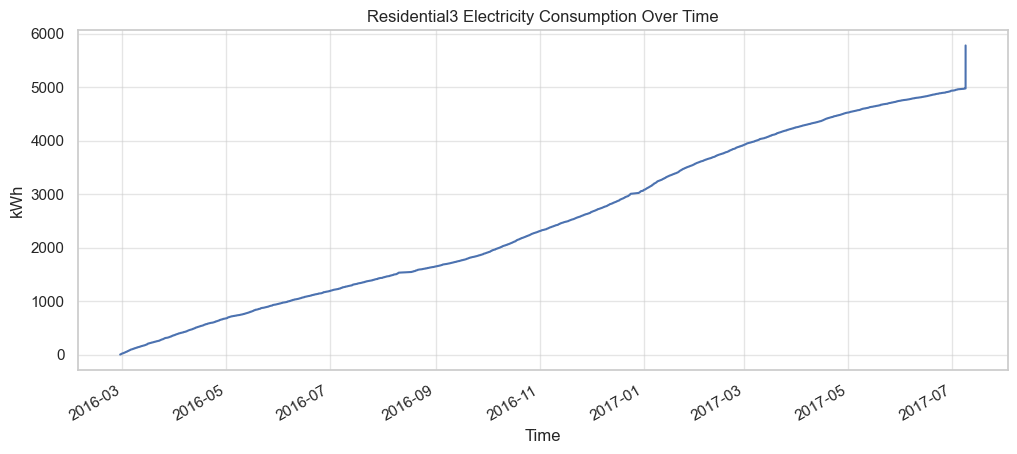

In [5]:
grid = "DE_KN_residential3_grid_import"

plt.figure(figsize=(12,5))
res[grid].plot()
plt.title("Residential3 Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("kWh")
plt.show()

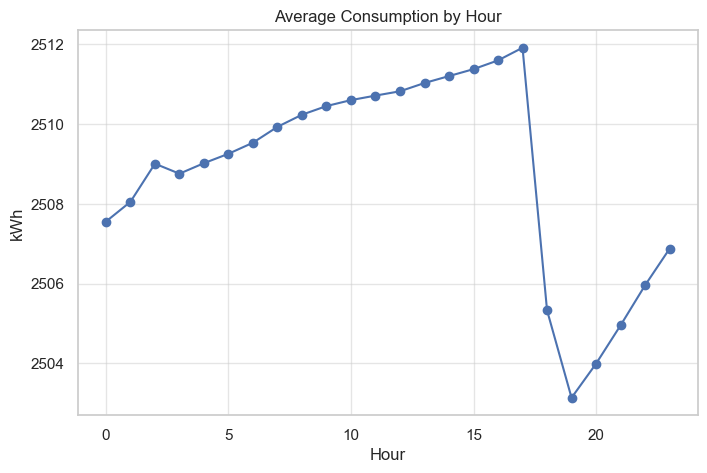

In [6]:
res["hour"] = res.index.hour

hourly = res.groupby("hour")[grid].mean()

plt.figure(figsize=(8,5))
hourly.plot(marker='o')
plt.title("Average Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("kWh")
plt.show()

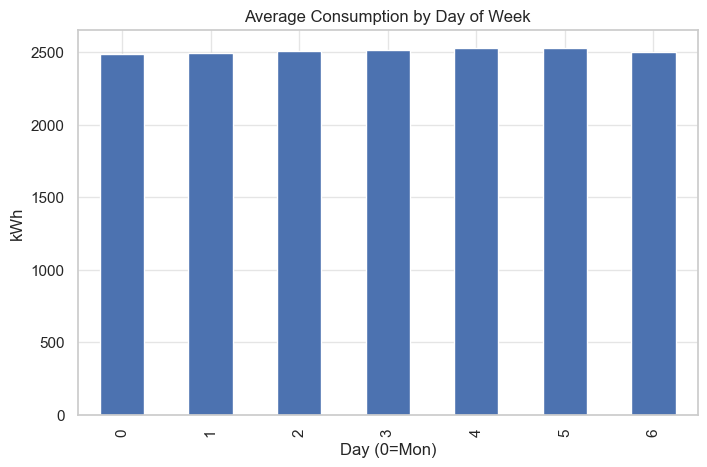

In [7]:
res["day"] = res.index.dayofweek

daily = res.groupby("day")[grid].mean()

plt.figure(figsize=(8,5))
daily.plot(kind="bar")
plt.title("Average Consumption by Day of Week")
plt.xlabel("Day (0=Mon)")
plt.ylabel("kWh")
plt.show()

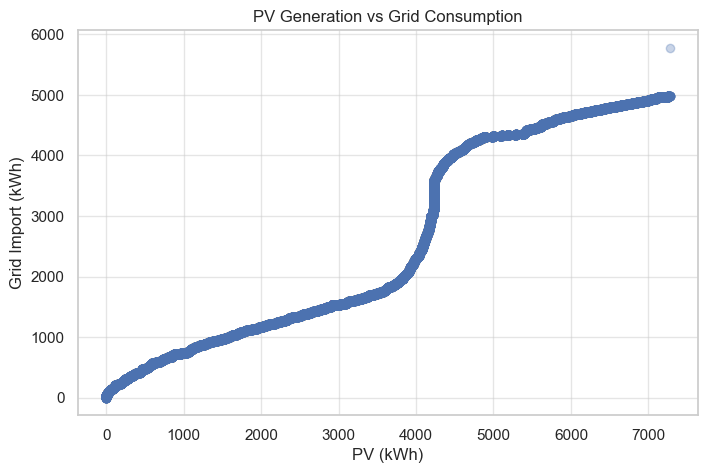

In [8]:
pv = "DE_KN_residential3_pv"

plt.figure(figsize=(8,5))
plt.scatter(res[pv], res[grid], alpha=0.3)
plt.title("PV Generation vs Grid Consumption")
plt.xlabel("PV (kWh)")
plt.ylabel("Grid Import (kWh)")
plt.show()

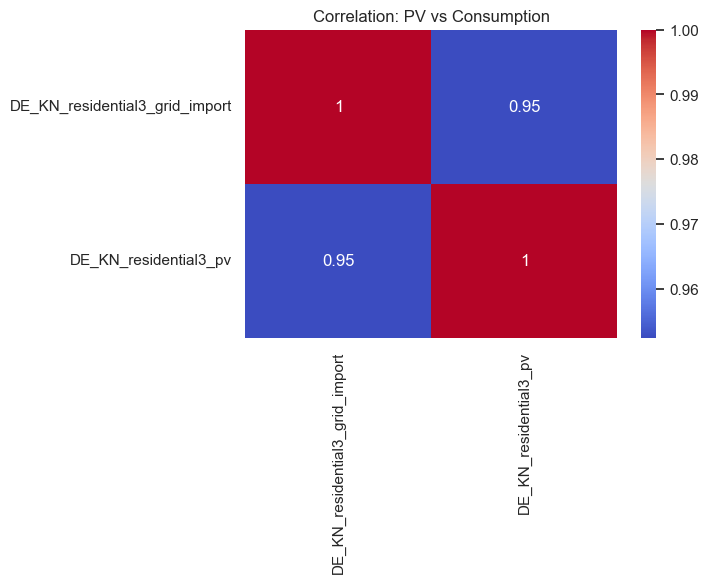

In [9]:
subset = res[[grid, pv]]

plt.figure(figsize=(6,4))
sns.heatmap(subset.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation: PV vs Consumption")
plt.show()

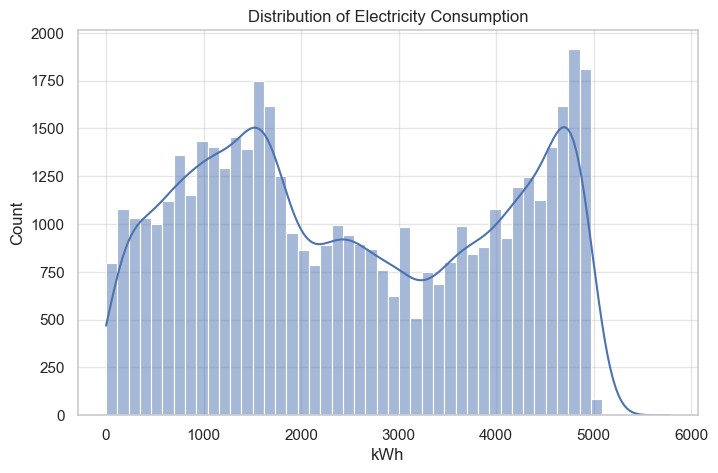

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(res[grid], bins=50, kde=True)
plt.title("Distribution of Electricity Consumption")
plt.xlabel("kWh")
plt.show()

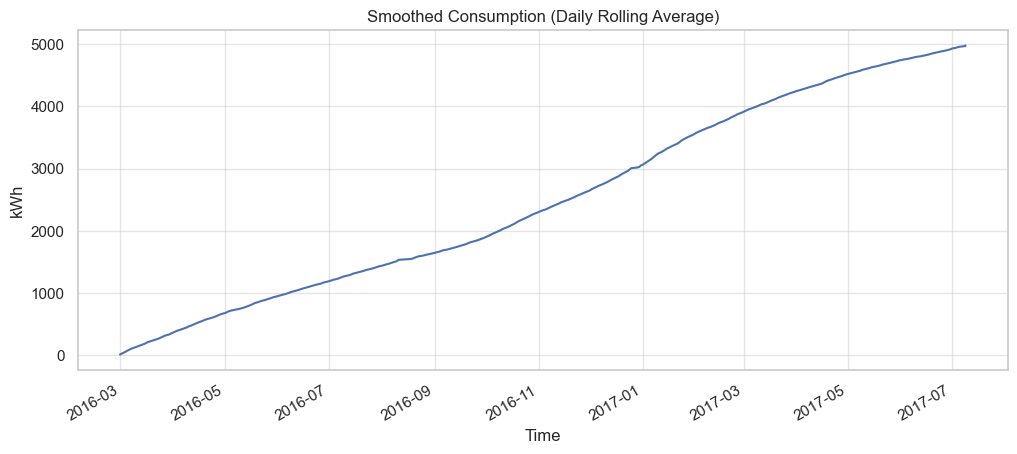

In [11]:
rolling = res[grid].rolling(window=96).mean()

plt.figure(figsize=(12,5))
rolling.plot()
plt.title("Smoothed Consumption (Daily Rolling Average)")
plt.xlabel("Time")
plt.ylabel("kWh")
plt.show()

## Key Insights

- Electricity consumption shows clear daily cycles.
- Peak usage occurs during evening hours.
- PV generation reduces grid dependency.
- Strong temporal patterns are visible in the data.